In [39]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import joblib  # to save models

In [40]:
df = pd.read_excel('Telco_customer_churn.xlsx')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [41]:
# Select only the relevant columns
cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']

# Get unique values for each column
unique_values = {col: df[col].unique() for col in cols}

# Display
for col, values in unique_values.items():
    print(f"Unique values in {col}:")
    print(values)
    print("\n")

Unique values in Tenure Months:
[ 2  8 28 49 10  1 47 17  5 34 11 15 18  9  7 12 25 68 55 37  3 27 20  4
 58 53 13  6 19 59 16 52 24 32 38 54 43 63 21 69 22 61 60 48 40 23 39 35
 56 65 33 30 45 46 62 70 50 44 71 26 14 41 66 64 29 42 67 51 31 57 36 72
  0]


Unique values in Monthly Charges:
[ 53.85  70.7   99.65 ... 108.35  63.1   78.7 ]


Unique values in Total Charges:
[108.15 151.65 820.5 ... 7362.9 346.45 6844.5]




In [42]:
# dropping all the unnecessary columns
cols_to_drop = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

df = df.drop(columns=cols_to_drop)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [44]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print(df['Total Charges'].dtype)

float64


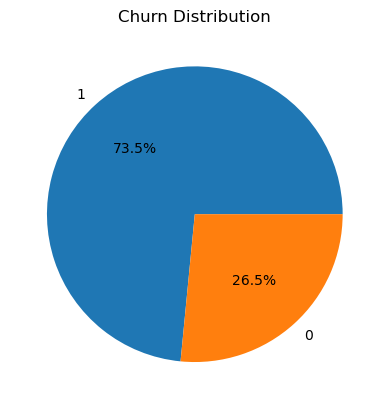

In [45]:
df['Churn Value'].value_counts()
df['Churn Value'].value_counts(normalize=True) * 100

plt.pie(df['Churn Value'].value_counts(), labels=df['Churn Value'].unique(), autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.show()

In [46]:
# apply loop check unique value without int or float in dataset
for col in df.columns:
    if df[col].dtype != np.number:
        print(f'{col} : {df[col].unique()}')

Gender : ['Male' 'Female']
Senior Citizen : ['No' 'Yes']
Partner : ['No' 'Yes']
Dependents : ['No' 'Yes']
Tenure Months : [ 2  8 28 49 10  1 47 17  5 34 11 15 18  9  7 12 25 68 55 37  3 27 20  4
 58 53 13  6 19 59 16 52 24 32 38 54 43 63 21 69 22 61 60 48 40 23 39 35
 56 65 33 30 45 46 62 70 50 44 71 26 14 41 66 64 29 42 67 51 31 57 36 72
  0]
Phone Service : ['Yes' 'No']
Multiple Lines : ['No' 'Yes' 'No phone service']
Internet Service : ['DSL' 'Fiber optic' 'No']
Online Security : ['Yes' 'No' 'No internet service']
Online Backup : ['Yes' 'No' 'No internet service']
Device Protection : ['No' 'Yes' 'No internet service']
Tech Support : ['No' 'Yes' 'No internet service']
Streaming TV : ['No' 'Yes' 'No internet service']
Streaming Movies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'Two year' 'One year']
Paperless Billing : ['Yes' 'No']
Payment Method : ['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Monthly Charges : [ 53.8

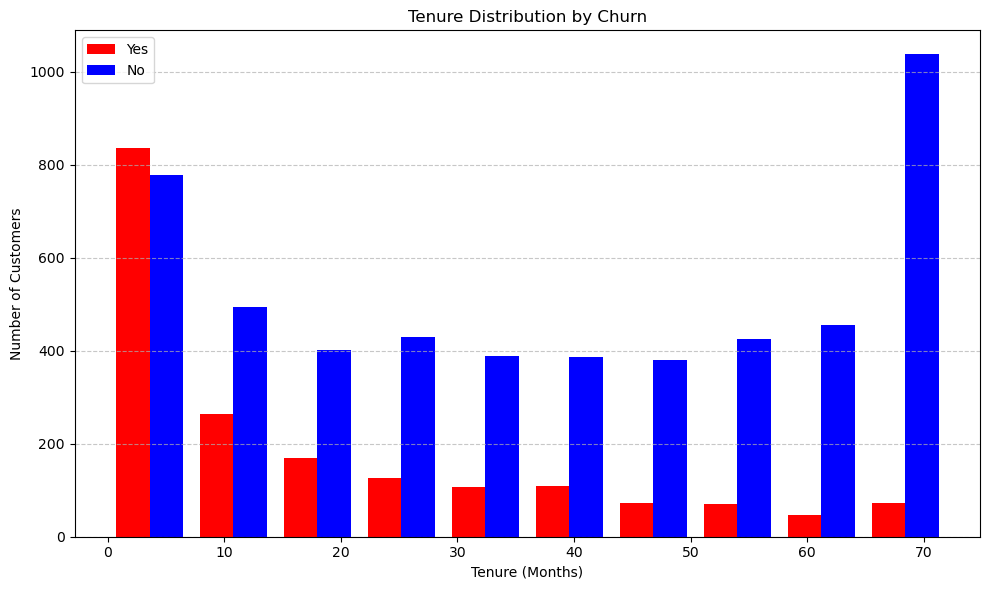

In [47]:
plt.figure(figsize=(10,6))
plt.hist([df[df['Churn Value']==1]['Tenure Months'], df[df['Churn Value']==0]['Tenure Months']], bins=10, color=['red', 'blue'], label=['Yes', 'No'])

plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

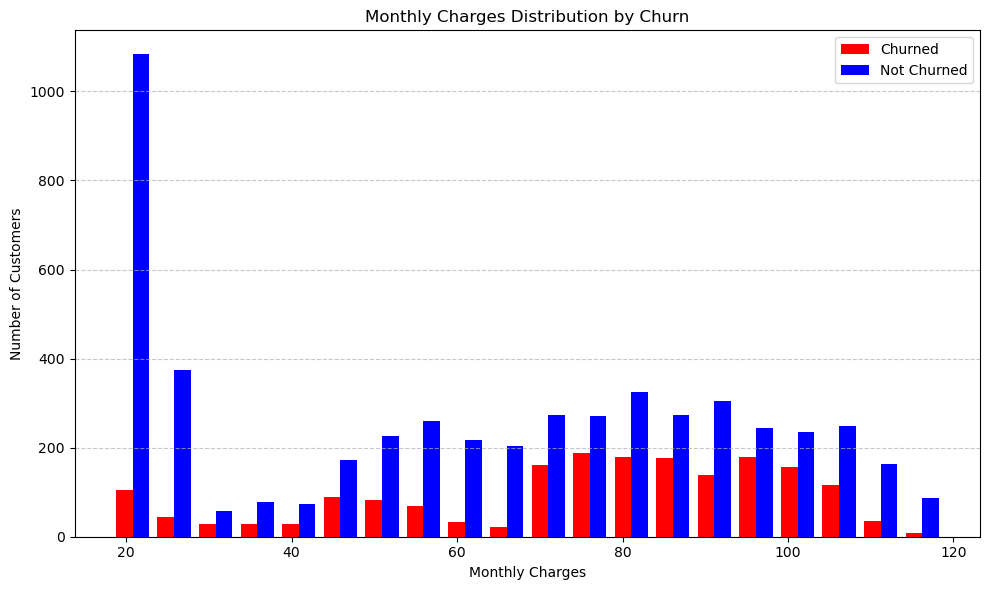

In [48]:
plt.figure(figsize=(10,6))
plt.hist([df[df['Churn Value'] == 1]['Monthly Charges'],
          df[df['Churn Value'] == 0]['Monthly Charges']],
         bins=20,
         color=['red', 'blue'],
         label=['Churned', 'Not Churned'])

plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

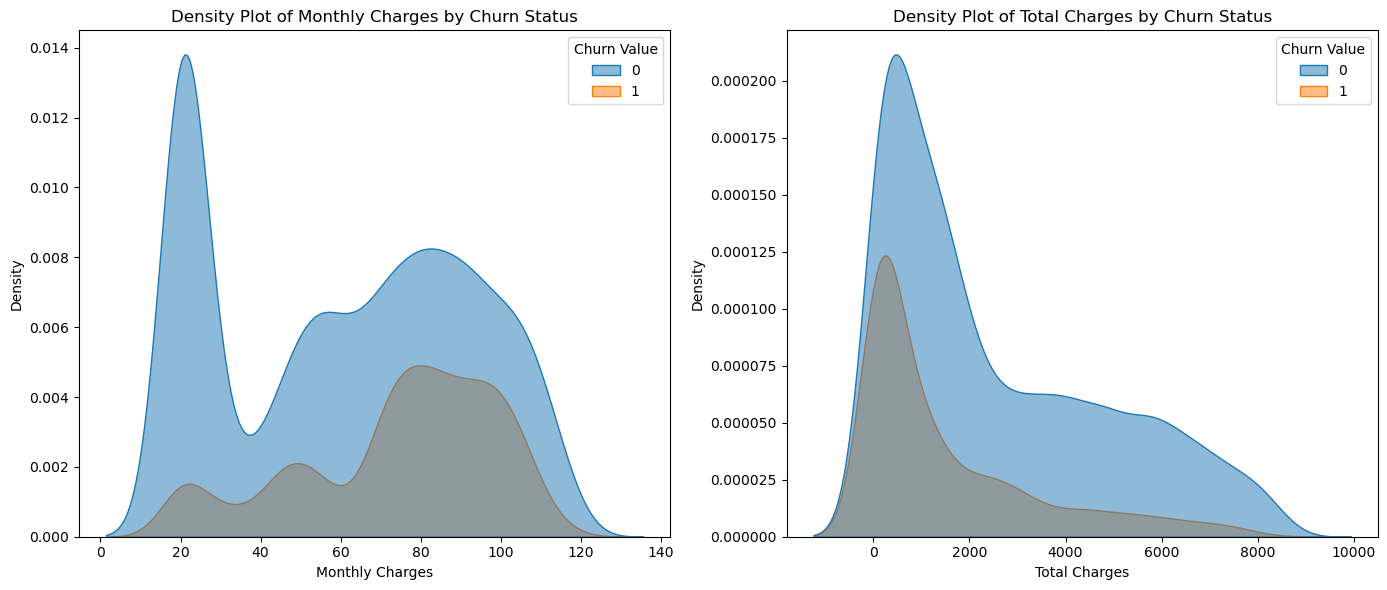

In [49]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Monthly Charges
sns.kdeplot(data=df, x="Monthly Charges", hue="Churn Value", fill=True, alpha=0.5, ax=axes[0])
axes[0].set_title('Density Plot of Monthly Charges by Churn Status')
axes[0].set_xlabel('Monthly Charges')
axes[0].set_ylabel('Density')

# Plot for Total Charges
sns.kdeplot(data=df, x="Total Charges", hue="Churn Value", fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Density Plot of Total Charges by Churn Status')
axes[1].set_xlabel('Total Charges')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()


In [50]:
print(df.isnull().sum())

Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Value           0
dtype: int64


In [51]:
df.dropna(inplace=True)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   object 
 1   Senior Citizen     7032 non-null   object 
 2   Partner            7032 non-null   object 
 3   Dependents         7032 non-null   object 
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   object 
 6   Multiple Lines     7032 non-null   object 
 7   Internet Service   7032 non-null   object 
 8   Online Security    7032 non-null   object 
 9   Online Backup      7032 non-null   object 
 10  Device Protection  7032 non-null   object 
 11  Tech Support       7032 non-null   object 
 12  Streaming TV       7032 non-null   object 
 13  Streaming Movies   7032 non-null   object 
 14  Contract           7032 non-null   object 
 15  Paperless Billing  7032 non-null   object 
 16  Payment Method     7032 non-n

In [53]:
# cleaning string columns by stripping whitespace
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [54]:
df

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0


In [55]:
# checking the outliers in the dataset  

df.select_dtypes(include=np.number).columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value'], dtype='object')

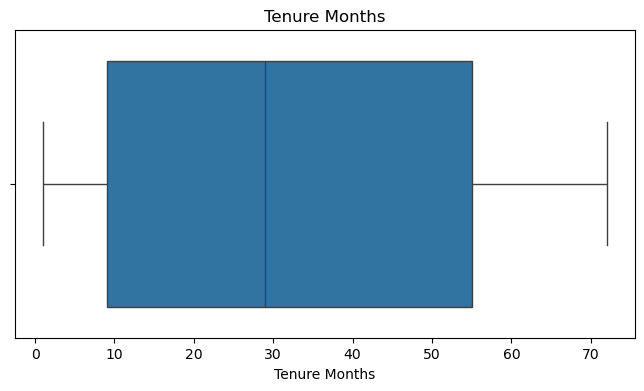

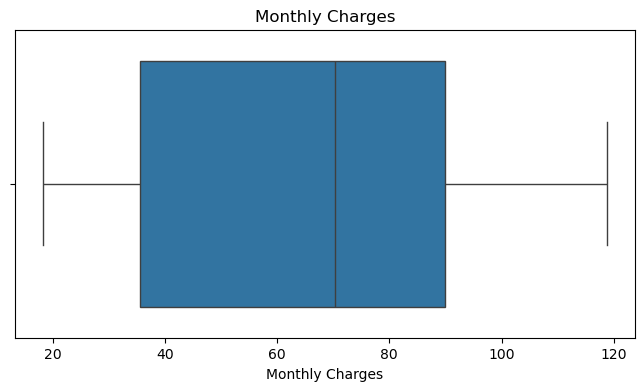

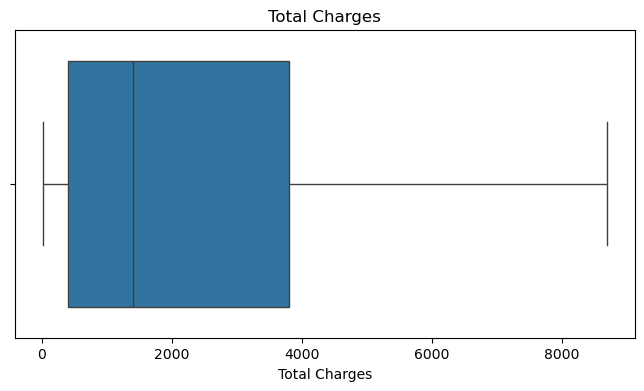

In [56]:
numeric_cols = df.select_dtypes(include=np.number).drop('Churn Value', axis=1).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [57]:
# now the data is cleaned and next step is for Data Transformation and Modeling

In [58]:
# from sklearn.preprocessing import StandardScaler



# Convert categorical columns to category type (before one-hot encoding)
obj_cols = df.select_dtypes(include=['object']).columns
df[obj_cols] = df[obj_cols].astype('category')

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=obj_cols, drop_first=True)

# Numerical columns
numerical_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']

# Standardize numerical columns
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [59]:
df.sample(15)

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
1382,-1.198760,1.010569,-0.878162,1,False,False,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
6362,-0.587601,-1.317924,-0.797005,0,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1849,-0.587601,1.161813,-0.197233,1,False,True,True,False,True,False,...,False,True,False,True,False,False,False,False,False,False
211,0.919926,1.170123,1.423271,1,False,True,False,False,True,False,...,False,True,False,True,True,False,True,False,True,False
1120,-0.628345,0.844367,-0.365811,1,True,False,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False
5258,-0.872808,-1.479140,-0.898699,0,False,False,False,False,True,False,...,True,False,True,False,False,False,False,False,False,False
1168,-1.280248,0.167924,-0.976547,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1908,1.368109,1.451005,2.114633,0,True,True,True,False,True,False,...,False,True,False,True,True,False,True,False,True,False
4846,1.082902,-0.997154,-0.133680,0,True,False,True,True,False,True,...,False,False,False,False,True,False,False,False,False,True
407,0.838438,1.372890,1.538178,1,False,False,True,False,True,False,...,False,True,False,True,True,False,True,False,False,False


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Tenure Months                           7032 non-null   float64
 1   Monthly Charges                         7032 non-null   float64
 2   Total Charges                           7032 non-null   float64
 3   Churn Value                             7032 non-null   int64  
 4   Gender_Male                             7032 non-null   bool   
 5   Senior Citizen_Yes                      7032 non-null   bool   
 6   Partner_Yes                             7032 non-null   bool   
 7   Dependents_Yes                          7032 non-null   bool   
 8   Phone Service_Yes                       7032 non-null   bool   
 9   Multiple Lines_No phone service         7032 non-null   bool   
 10  Multiple Lines_Yes                      7032 non-null   bool   
 

In [61]:
# splitting the dataset into train and test set

x = df.drop('Churn Value', axis=1)
y = df['Churn Value']

joblib.dump(x.columns, 'model_columns.pkl')

['model_columns.pkl']

In [62]:
# from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [63]:
# Machine Learning Libraries

# from sklearn.metrics import accuracy_score

# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB

In [64]:
# making a dictionary of all the models to loop through them and find the best one
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

# training and evaluating each model and storing the results in a dictionary

results = {}

for name, model in models.items():
    
    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc

In [65]:
# Show the results
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.8124
Decision Tree: 0.7292
Random Forest: 0.7960
SVM: 0.8117
KNN: 0.7775
Naive Bayes: 0.6951


In [66]:
# Best Model
best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", results[best_model])


Best Model: Logistic Regression
Best Accuracy: 0.8123667377398721


Accuracy: 0.8123667377398721

Confusion Matrix:
[[914  98]
 [166 229]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1012
           1       0.70      0.58      0.63       395

    accuracy                           0.81      1407
   macro avg       0.77      0.74      0.75      1407
weighted avg       0.81      0.81      0.81      1407


ROC AUC Score: 0.8622904888177315


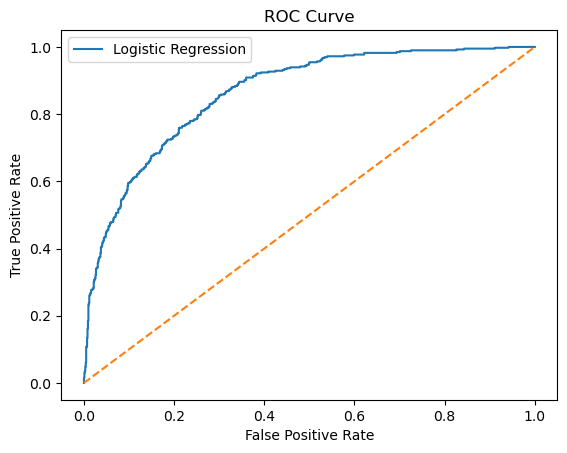


Top 10 Features Influencing Churn:
                            Feature  Coefficient
2                     Total Charges     0.723268
1                   Monthly Charges     0.410702
26            Paperless Billing_Yes     0.403534
10     Internet Service_Fiber optic     0.308300
5                       Partner_Yes     0.304499
28  Payment Method_Electronic check     0.265449
9                Multiple Lines_Yes     0.158940
4                Senior Citizen_Yes     0.131597
8   Multiple Lines_No phone service     0.100278
23             Streaming Movies_Yes     0.049754


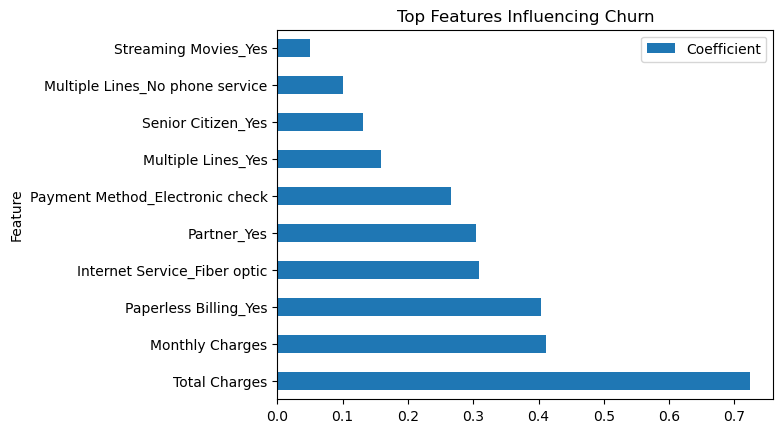

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import pandas as pd
import matplotlib.pyplot as plt

log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)

y_pred = log_model.predict(x_test)
y_prob = log_model.predict_proba(x_test)[:,1]

accuracy = log_model.score(x_test, y_test)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_prob)
print("\nROC AUC Score:", roc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": log_model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)

print("\nTop 10 Features Influencing Churn:")
print(importance.head(10))

importance.head(10).plot(
    x="Feature",
    y="Coefficient",
    kind="barh"
)

plt.title("Top Features Influencing Churn")
plt.show()

In [68]:
import joblib

# Replace 'model' with your actual variable name (e.g., your LogisticRegression or RandomForest object)
joblib.dump(model, 'churn_model.pkl')

['churn_model.pkl']

In [69]:
import joblib

# Use the actual variable name from your script: log_model
joblib.dump(log_model, 'churn_model.pkl')

# Save the column names so the app knows the exact order/names
joblib.dump(x.columns.tolist(), 'model_columns.pkl')

print("Model and columns saved successfully!")

Model and columns saved successfully!
